In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diamonds.csv")
df.head(30)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    50000 non-null  float64
 5   table    50000 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


In [ ]:
df.shape

(50000, 10)

In [ ]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(126)

In [ ]:
df = df.drop_duplicates()

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
          (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
df.shape

(43955, 10)

In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,43955.000000,43955.000000,43955.000000,43955.000000,43955.000000,43955.000000,43955.000000
mean,0.710105,61.786868,57.262489,3123.577181,5.550240,5.555175,3.430650
std,0.371726,1.107175,2.019675,2763.645212,0.980695,0.974760,0.606715
min,0.200000,58.800000,52.000000,326.000000,3.730000,3.680000,1.410000
25%,0.380000,61.100000,56.000000,891.000000,4.640000,4.650000,2.860000
50%,0.610000,61.900000,57.000000,2074.000000,5.460000,5.470000,3.370000
75%,1.010000,62.500000,59.000000,4656.000000,6.410000,6.410000,3.980000
max,2.000000,64.700000,63.500000,11950.000000,8.280000,8.270000,5.300000


In [ ]:
df.select_dtypes(include="object").describe()

,cut,color,clarity
count,43955,43955,43955
unique,5,7,8
top,Ideal,G,SI1
freq,18774,9319,10699


In [ ]:
df.mean(numeric_only=True)

,0
carat,0.710105
depth,61.786868
table,57.262489
price,3123.577181
x,5.550240
y,5.555175
z,3.430650


In [ ]:
df.median(numeric_only=True)

,0
carat,0.61
depth,61.90
table,57.00
price,2074.00
x,5.46
y,5.47
z,3.37


In [ ]:
df.mode().head(1)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.3,Ideal,G,SI1,62.0,56.0,605,4.37,4.34,2.7


In [ ]:
df.std(numeric_only=True)

,0
carat,0.371726
depth,1.107175
table,2.019675
price,2763.645212
x,0.980695
y,0.974760
z,0.606715


In [ ]:
corr = df.corr(numeric_only=True)
corr

,carat,depth,table,price,x,y,z
carat,1.000000,0.037264,0.188146,0.922762,0.986201,0.985417,0.984975
depth,0.037264,1.000000,-0.239653,0.007035,-0.009380,-0.011009,0.093963
table,0.188146,-0.239653,1.000000,0.138122,0.187190,0.181778,0.159971
price,0.922762,0.007035,0.138122,1.000000,0.899568,0.900714,0.896197
x,0.986201,-0.009380,0.187190,0.899568,1.000000,0.998593,0.993295
y,0.985417,-0.011009,0.181778,0.900714,0.998593,1.000000,0.993159
z,0.984975,0.093963,0.159971,0.896197,0.993295,0.993159,1.000000


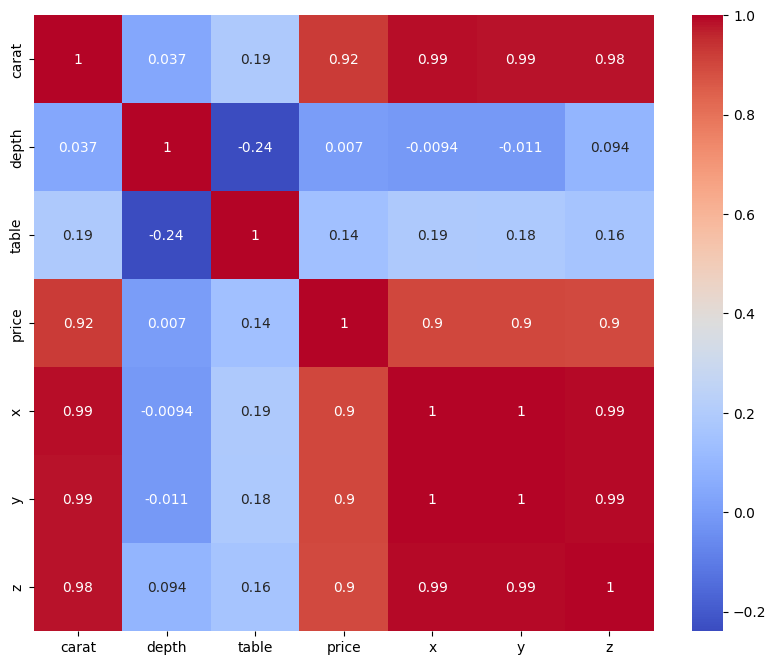

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

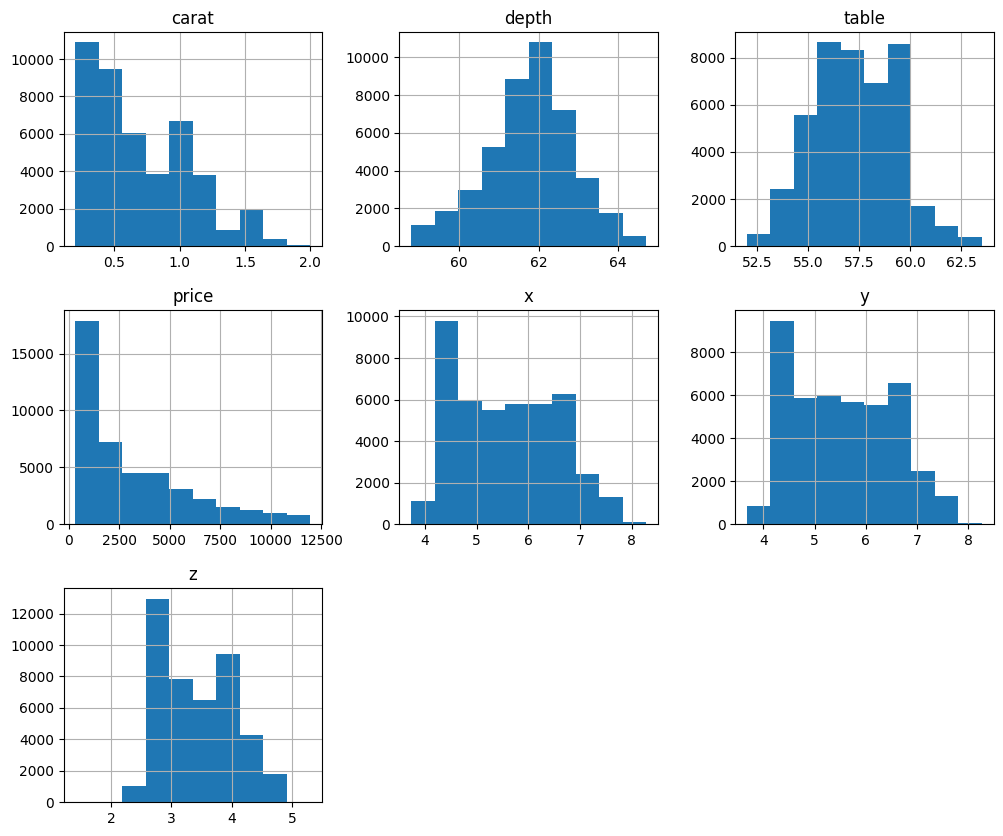

In [ ]:
df.hist(figsize=(12,10))
plt.show()

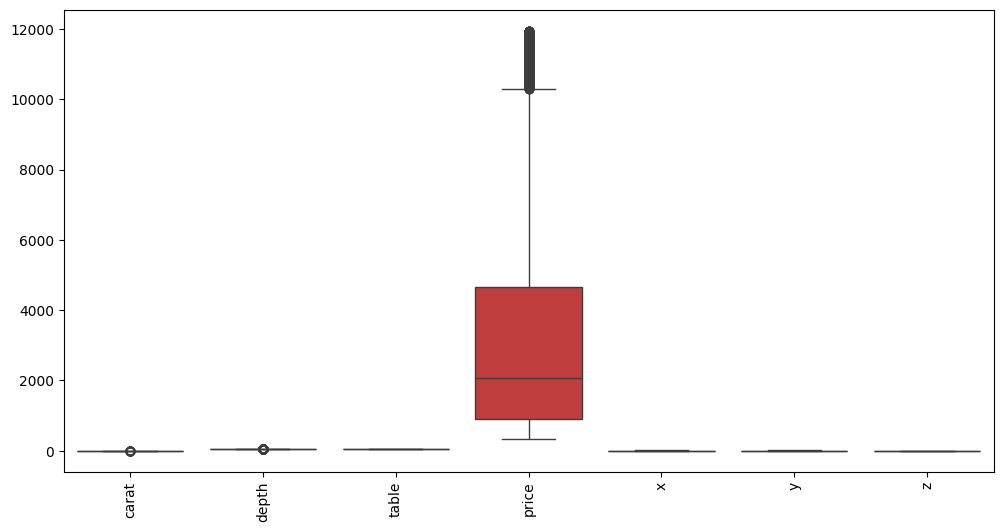

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

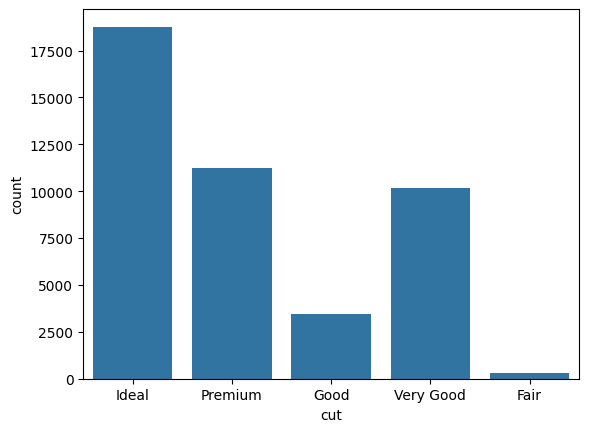

In [ ]:
sns.countplot(x="cut", data=df)
plt.show()

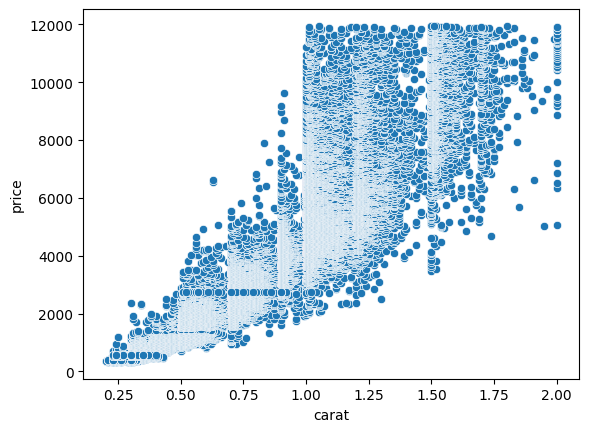

In [ ]:
sns.scatterplot(x="carat", y="price", data=df)
plt.show()

Business Insight Report:

1)Dataset was successfully loaded and explored.

2)Missing values were handled.

3)Duplicate records were removed.

3)Outliers were detected and treated using the IQR method.

4)Numerical and categorical features were analyzed.

5)Statistical measures (mean, median, mode, standard deviation) were calculated.

6)Correlation analysis was performed.

7)Heatmap, histogram, box plot, count plot, and scatter plot were created.

8)Higher carat diamonds generally have higher prices.

9)The cleaned dataset is ready for further business analysis or machine learning.